# 💾 The data: [cholera_dataset.csv](https://www.kaggle.com/datasets/imdevskp/cholera-dataset?select=data.csv)

In [124]:
# import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statistics as st

## 1. Load and Inspect

In [125]:
# Load the Dataset

# Read the csv file into a pandas DataFrame
health_data = pd.read_csv('cholera data.csv')

print('Data loaded successfully!')
print(f'Shape: {health_data.shape[0]} rows x {health_data.shape[1]} columns')

Data loaded successfully!
Shape: 2492 rows x 6 columns


In [126]:
# Inspect the data

# View the first few rows to understand the structure
health_data.head(20)

,Country,Year,Number of reported cases of cholera,Number of reported deaths from cholera,Cholera case fatality rate,WHO Region
0,Afghanistan,2016,677,5,0.7,Eastern Mediterranean
1,Afghanistan,2015,58064,8,0.01,Eastern Mediterranean
2,Afghanistan,2014,45481,4,0.0,Eastern Mediterranean
3,Afghanistan,2013,3957,14,0.35,Eastern Mediterranean
4,Afghanistan,2012,12,0,0.1,Eastern Mediterranean
5,Afghanistan,2011,3733,44,1.18,Eastern Mediterranean
6,Afghanistan,2010,2369,10,0.42,Eastern Mediterranean
7,Afghanistan,2009,662,11,1.66,Eastern Mediterranean
8,Afghanistan,2008,4384,22,0.5,Eastern Mediterranean
9,Afghanistan,2005,33,0,0,Eastern Mediterranean


In [127]:
# View data types and non-null count for each column
health_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2492 entries, 0 to 2491
Data columns (total 6 columns):
 #   Column                                  Non-Null Count  Dtype 
---  ------                                  --------------  ----- 
 0   Country                                 2492 non-null   object
 1   Year                                    2492 non-null   int64 
 2   Number of reported cases of cholera     2470 non-null   object
 3   Number of reported deaths from cholera  2375 non-null   object
 4   Cholera case fatality rate              2365 non-null   object
 5   WHO Region                              2492 non-null   object
dtypes: int64(1), object(5)
memory usage: 116.9+ KB


**Issues Identified**
- Long column names: Some column names are too long which may reduced code readability.

- Incorrect Data Types: The `Number of reported cases of cholera`, `Number of reported deaths from cholera` and `Cholera case fatality rate` columns are not stored as numerical data types.

- Missing Values: There are missing values in the he `Number of reported cases of cholera`, `Number of reported deaths from cholera` and `Cholera case fatality rate`columns.

In [128]:
# Create copy of DataFrame before cleaning
health_data_1 = health_data.copy()

print('Data copied successfully!')
print(f'Shape: {health_data_1.shape[0]} rows x {health_data_1.shape[1]} columns')

Data copied successfully!
Shape: 2492 rows x 6 columns


In [129]:
# Rename columns using a dictionary
health_data_1 = health_data_1.rename(columns={
    'Number of reported cases of cholera': 'No. of Cases',
    'Number of reported deaths from cholera': 'No. of Deaths',
    'Cholera case fatality rate': 'Case Fatality Rate'
})

# Verify change
health_data_1.head(2)

,Country,Year,No. of Cases,No. of Deaths,Case Fatality Rate,WHO Region
0,Afghanistan,2016,677,5,0.7,Eastern Mediterranean
1,Afghanistan,2015,58064,8,0.01,Eastern Mediterranean


`No. of Cases` and `No. of Deaths` columns represent discrete counts and should ideally be integers(whole numbers). However, due to the presence of "NaN" values in these columns, a standard `astype(int)` will throw a `ValueError`.

First, I will convert to float and once I have handled the missing values, I will convert to integer

In [130]:
# Convert the string values to floats
# Create a function that checks if values can be converted  to float
def convert_float(x):
    try:
        float(x)
    except:
        return False  
    return True

In [131]:
# Apply function to columns of interest
health_data_1['No. of Cases'].apply(convert_float)
health_data_1['No. of Deaths'].apply(convert_float)
health_data_1['Case Fatality Rate'].apply(convert_float)

0       True
1       True
2       True
3       True
4       True
        ... 
2487    True
2488    True
2489    True
2490    True
2491    True
Name: Case Fatality Rate, Length: 2492, dtype: bool

In [132]:
# View rows with False values(rows that cannot be converted to float)
health_data_1[~health_data_1['No. of Cases'].apply(convert_float)]

,Country,Year,No. of Cases,No. of Deaths,Case Fatality Rate,WHO Region
1059,Iraq,2016,3 5,0 0,0.0 0.0,Eastern Mediterranean


In [133]:
health_data_1[~health_data_1['No. of Deaths'].apply(convert_float)]

,Country,Year,No. of Cases,No. of Deaths,Case Fatality Rate,WHO Region
761,Germany,2016,1,Unknown,Unknown,Europe
1059,Iraq,2016,3 5,0 0,0.0 0.0,Eastern Mediterranean


In [134]:
health_data_1[~health_data_1['Case Fatality Rate'].apply(convert_float)]

,Country,Year,No. of Cases,No. of Deaths,Case Fatality Rate,WHO Region
761,Germany,2016,1,Unknown,Unknown,Europe
1059,Iraq,2016,3 5,0 0,0.0 0.0,Eastern Mediterranean


After running the check, the following data entry errors were identified:
- The Germany 2016 record contains the string 'Unknown' instaed of 'NaN' value.

- The Iraq 2016 record contains spaced entries '3 5', '0 0' and '0.0 0.0'.

In [135]:
# Deal with values that cannot be converted to float
health_data_1['No. of Cases'] = health_data_1['No. of Cases'].str.replace(' ', '')
health_data_1['No. of Deaths'] = health_data_1['No. of Deaths'].str.replace(' ', '')
health_data_1['Case Fatality Rate'] = health_data_1['Case Fatality Rate'].str.replace('0.0 0.0', '0.0')
health_data_1['No. of Deaths'] = health_data_1['No. of Deaths'].replace('Unknown', np.nan)
health_data_1['Case Fatality Rate'] = health_data_1['Case Fatality Rate'].replace('Unknown', np.nan)

In [136]:
# Confirm the fix
display(health_data_1[~health_data_1['No. of Cases'].apply(convert_float)])
display(health_data_1[~health_data_1['No. of Deaths'].apply(convert_float)])
display(health_data_1[~health_data_1['Case Fatality Rate'].apply(convert_float)])

,Country,Year,No. of Cases,No. of Deaths,Case Fatality Rate,WHO Region


,Country,Year,No. of Cases,No. of Deaths,Case Fatality Rate,WHO Region


,Country,Year,No. of Cases,No. of Deaths,Case Fatality Rate,WHO Region


In [137]:
# Convert columns of interest  to float
health_data_1['No. of Cases'] = health_data_1['No. of Cases'].astype('float64')
health_data_1['No. of Deaths'] = health_data_1['No. of Deaths'].astype('float64')
health_data_1['Case Fatality Rate'] = health_data_1['Case Fatality Rate'].astype('float64')

In [138]:
# Confirm datatype change
health_data_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2492 entries, 0 to 2491
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Country             2492 non-null   object 
 1   Year                2492 non-null   int64  
 2   No. of Cases        2470 non-null   float64
 3   No. of Deaths       2374 non-null   float64
 4   Case Fatality Rate  2364 non-null   float64
 5   WHO Region          2492 non-null   object 
dtypes: float64(3), int64(1), object(2)
memory usage: 116.9+ KB


## 2. Remove Duplicates & Invalid Rows

In [139]:
# Check for duplicate rows in the dataset
print(f'Number of duplicate rows: {health_data_1.duplicated().sum()}')

Number of duplicate rows: 0


In [140]:
# View statistical summary of the numeric columns
health_data_1.describe()

,Year,No. of Cases,No. of Deaths,Case Fatality Rate
count,2492.000000,2470.000000,2374.000000,2364.000000
mean,1992.343098,3716.887854,377.929233,5.755592
std,14.834151,14902.071628,3569.539062,15.563678
min,1949.000000,0.000000,0.000000,0.000000
25%,1981.000000,10.000000,0.000000,0.000000
50%,1994.000000,241.500000,7.000000,1.500000
75%,2004.000000,1890.250000,59.000000,5.245000
max,2016.000000,340311.000000,124227.000000,450.000000


**Observation**
- The maximum Case Fatality Rate(CFR) is 450. This is unusual.

**Cleaning Decision**
- Filter dataset to include only records where `Number of Deaths` > `Number of Cases`

**Reasoning**
- When number of deaths is higher than the number of confirmed cases, CFR will exceed 100 %
- We cannot have more people dying from a disease than the number of people who actually caught it and thus such records represent errors.

In [141]:
# Create 2nd Checkpoint before filtering
health_data_2 = health_data_1.copy()

print('Data copied successfully!')
print(f'Shape: {health_data_2.shape[0]} rows x {health_data_2.shape[1]} columns')

Data copied successfully!
Shape: 2492 rows x 6 columns


In [142]:
# Filter for criteria
health_data_2[health_data_2['No. of Deaths'] > health_data_2['No. of Cases']]

,Country,Year,No. of Cases,No. of Deaths,Case Fatality Rate,WHO Region
1094,Italy,1998,2.0,9.0,450.0,Europe


In [143]:
# Remove the rows
health_data_2 = health_data_2[~(health_data_2['No. of Deaths'] > health_data_2['No. of Cases'])]

print('Data filtered successfully!')
print(f'Shape: {health_data_2.shape[0]} rows x {health_data_2.shape[1]} columns')

Data filtered successfully!
Shape: 2491 rows x 6 columns


In [144]:
# View summary statistics of numeric columns
health_data_2.describe()

,Year,No. of Cases,No. of Deaths,Case Fatality Rate
count,2491.000000,2469.000000,2373.000000,2363.000000
mean,1992.340827,3718.392467,378.084703,5.567592
std,14.836697,14904.902726,3570.283376,12.599281
min,1949.000000,0.000000,0.000000,0.000000
25%,1981.000000,10.000000,0.000000,0.000000
50%,1994.000000,243.000000,7.000000,1.500000
75%,2004.000000,1892.000000,59.000000,5.235000
max,2016.000000,340311.000000,124227.000000,100.000000


## 3. Handle Missing Values

In [145]:
# View missing values in detail

print(f"Number of rows in dataframe: {len(health_data_2)}\n")

missing_count = health_data_2.isnull().sum()   # count of missing value in each column
missing_percent = health_data_2.isnull().sum() / len(health_data_2) * 100   # percent of missing values in each column

missing_data = pd.DataFrame({
    'Missing_Count': missing_count,
    'Percentage': missing_percent
})
print(missing_data[missing_data['Missing_Count'] > 0])

Number of rows in dataframe: 2491

                    Missing_Count  Percentage
No. of Cases                   22    0.883179
No. of Deaths                 118    4.737053
Case Fatality Rate            128    5.138499


 **5% or less is generally considered to be low level of missingness in public health data**

### 3.1 Visualize the distribution 

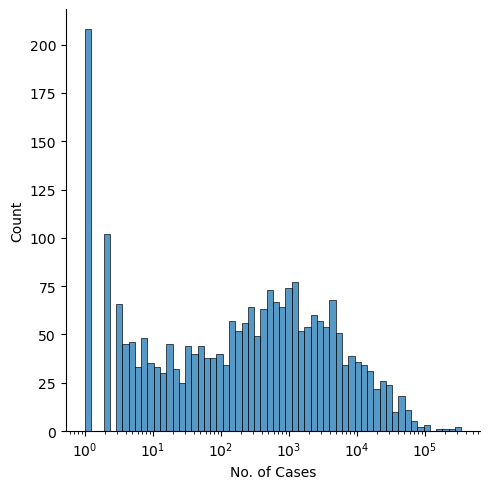

In [146]:
# View distribution of columns with missing values
sns.displot(data=health_data_2, x='No. of Cases', bins=60, kde=False, log_scale=(True, False)) # Distribution of Cases column

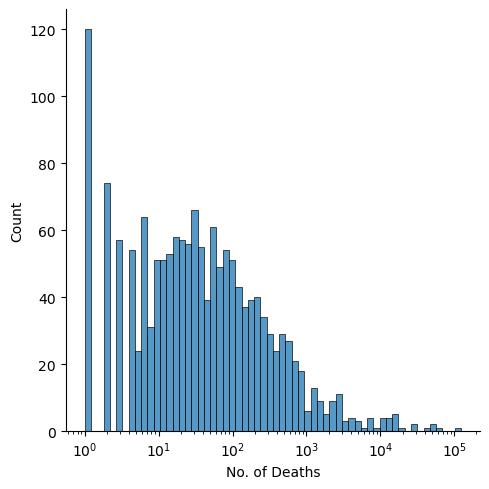

In [147]:
sns.displot(data=health_data_2, x='No. of Deaths', bins=60, kde=False, log_scale=(True, False)) # Distribution of Deaths column

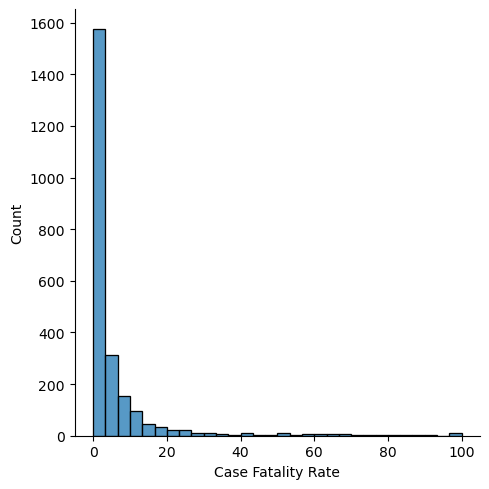

In [148]:
sns.displot(data=health_data_2, x='Case Fatality Rate', bins=30, kde=False) # # Distribution of Case Fatality Rate column

**Observation:**

- The visulaisations show that the distributions for `No. of Cases`, `No. of Deaths` and `Case Fatality Rate` are right-skewed.

**Imputation Strategy**

- I will use the existing relationships between variables to fill in the blanks for partially complete records:
   - If deaths are missing: Estimate them by multiplying No. of Cases by the regional Case Fatality Rate (CFR).
   - If cases are missing: Calculate them by dividing No. of Deaths by the Case Fatality Rate (CFR)


- The Median of values is  not significantly affected by skewness and outliers in the way that the mean is, and thus, is ideal for imputation in this situation where the distributions are skewed towards the right .

- Instead of using the global median , filling missing values using the median for that specific Region and Year(grouped imputation) will be best for the sake of balancing chnages over years with geographical patterns (making sure a missing value in 1970s Africa doesn't get filled with a number from 2010s Europe).

  
 - To maintain mathematical integrity, I will not impute the the Case Fatality Rate (CFR)  directly. Instead, I will recalculated using the formula:
    `CFR = (Deaths/Cases)* 100`,  after the no. of cases and no. of deaths have been filled.

In [150]:
# Create 3rd Pipeline
health_data_3 = health_data_2.copy()

### 3.2 Imputation using  existing relationships between variables

In [151]:
# View rows with missing No. of cases and existing Deaths and CFR
health_data_3[(health_data_3['No. of Cases'].isnull()) &
               (health_data_3['No. of Deaths'].notnull()) &
               (health_data_3['Case Fatality Rate'].notnull())]

,Country,Year,No. of Cases,No. of Deaths,Case Fatality Rate,WHO Region


In [152]:
# View rows with missing Deaths and exsisting Cases and CFR
health_data_3[(health_data_3['No. of Deaths'].isnull()) &
               (health_data_3['No. of Cases'].notnull()) &
               (health_data_3['Case Fatality Rate'].notnull())]

,Country,Year,No. of Cases,No. of Deaths,Case Fatality Rate,WHO Region
260,Brunei Darussalam,2011,3.0,NaN,0.0,Western Pacific
412,Canada,2011,9.0,NaN,0.0,Americas
472,China,2011,26.0,NaN,0.0,Western Pacific
1106,Japan,2011,12.0,NaN,0.0,Western Pacific
1229,Liberia,2011,1146.0,NaN,0.0,Africa
1480,Myanmar,2011,16.0,NaN,0.0,South-East Asia
1533,Nepal,2011,12.0,NaN,0.0,South-East Asia
1788,Republic of Korea,2011,3.0,NaN,0.0,Western Pacific
1884,Senegal,2011,5.0,NaN,0.0,Africa
2357,Viet Nam,2011,3.0,NaN,0.0,Western Pacific


In [153]:
# Create a filter for the rows of interest
missing_deaths = ((health_data_3['No. of Deaths'].isnull()) & 
       (health_data_3['No. of Cases'].notnull()) & 
       (health_data_3['Case Fatality Rate'].notnull()))

# Perform calculations on  those specific rows
# Formula: Deaths = Cases * (CFR / 100)
health_data_3.loc[missing_deaths, 'No. of Deaths'] = (
    health_data_3.loc[missing_deaths, 'No. of Cases'] * (health_data_3.loc[missing_deaths, 'Case Fatality Rate'] / 100)
)

In [154]:
# Check to see of those specific rows are now filled
health_data_3.loc[missing_deaths]

,Country,Year,No. of Cases,No. of Deaths,Case Fatality Rate,WHO Region
260,Brunei Darussalam,2011,3.0,0.0,0.0,Western Pacific
412,Canada,2011,9.0,0.0,0.0,Americas
472,China,2011,26.0,0.0,0.0,Western Pacific
1106,Japan,2011,12.0,0.0,0.0,Western Pacific
1229,Liberia,2011,1146.0,0.0,0.0,Africa
1480,Myanmar,2011,16.0,0.0,0.0,South-East Asia
1533,Nepal,2011,12.0,0.0,0.0,South-East Asia
1788,Republic of Korea,2011,3.0,0.0,0.0,Western Pacific
1884,Senegal,2011,5.0,0.0,0.0,Africa
2357,Viet Nam,2011,3.0,0.0,0.0,Western Pacific


### 3.3 Imputation using group median

**Potential Risks of Group Median Stategy**
- Ignores year-over-year growth

-  It assumes countries would have followed the regional trend. If that country had a unique healthcare system or isolated outbreak, the median will wash that detail away

- If a region has few records, the median might not be reflective.

In [155]:
# Ensure each region has enough records 
records_per_region = health_data_3.groupby('WHO Region')['Year'].count()
print("Records per Region:")
print(records_per_region)

Records per Region:
WHO Region
Africa                   991
Americas                 256
Eastern Mediterranean    235
Europe                   326
South-East Asia          292
Western Pacific          391
Name: Year, dtype: int64


In [156]:
# Check the number of countries that have records per region and year
records_per_region_year = health_data_3.groupby(['WHO Region', 'Year'])['Country'].count()
print("Records per Region and Year")
print(records_per_region_year)

Records per Region and Year
WHO Region       Year
Africa           1970    12
                 1971    20
                 1972    15
                 1973    15
                 1974    17
                         ..
Western Pacific  2012     6
                 2013     7
                 2014     6
                 2015     4
                 2016     5
Name: Country, Length: 314, dtype: int64


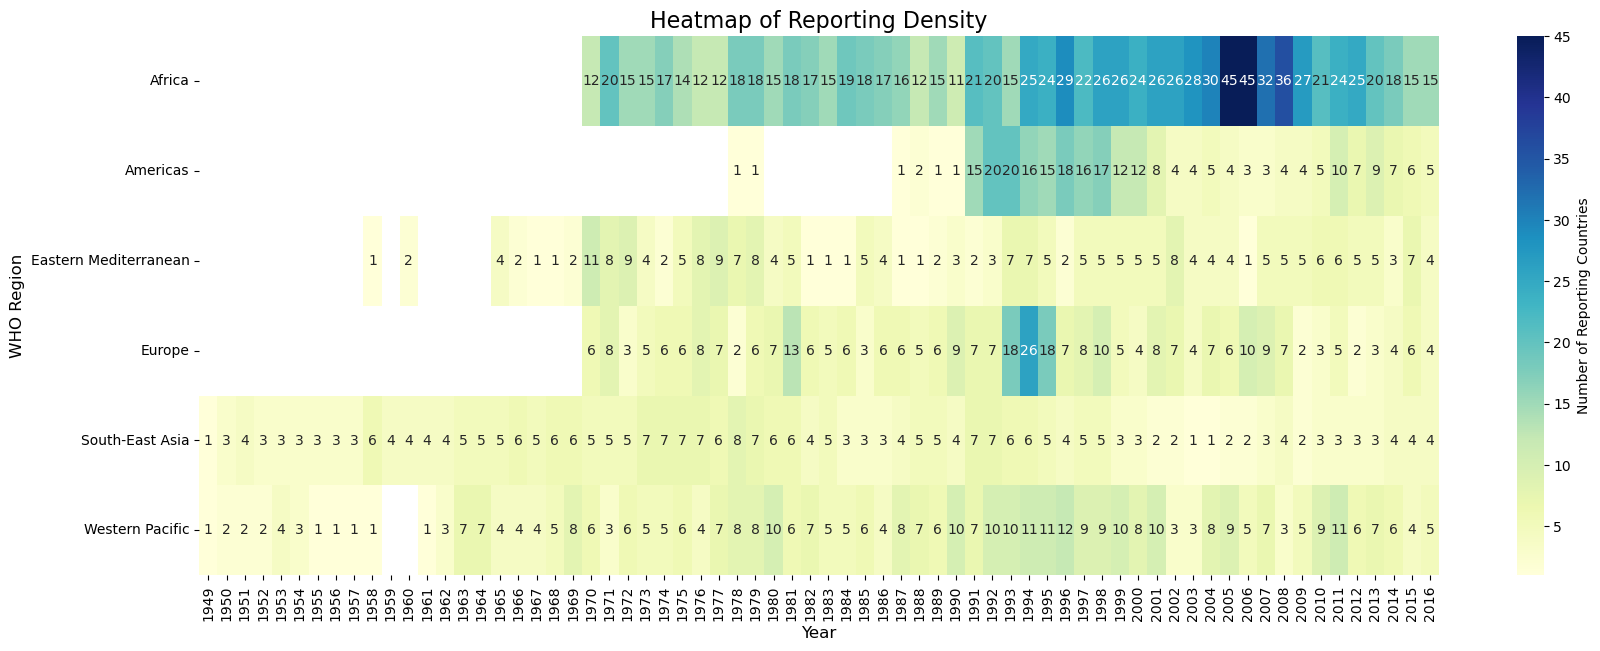

In [157]:
# Reset the index 
plot_data = records_per_region_year.reset_index(name='Country Count')

# Reshape the data into a matrix format
heatmap_matrix = plot_data.pivot(index='WHO Region', columns='Year', values='Country Count')

# Create the heatmap
plt.figure(figsize=(20, 7))
sns.heatmap(
    heatmap_matrix, 
    annot=True,  # Show the number in the cells
    cmap='YlGnBu',  # Yellow-Green-Blue (light colors = few records, dark = many)
    cbar_kws={'label': 'Number of Reporting Countries'}
)

plt.title('Heatmap of Reporting Density' , fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('WHO Region', fontsize=12)
plt.show()

- The heatmap shows that certain regions and years have few reporting countries.
  
- In order to account for a situation where a specific region-year combination lacks enough data to derive a median(e.g., if all the records for  Africa in 2010 possess missing values), I implemented a a fallback mechanism that uses the broader regional median, calculated across all years, to ensure there is  a median to be imputed.

- To prevent impossible data points, such as imputed deaths exceeding number of cases due to using a regional median and consquently causing the Case Fatality Rate to exceed 100%, I carried out the following steps:
  - Filled missing `No. of Cases`  using the median strategy
  - Generated a temporaray Case Fatatlity Rate(CFR) column to store median fatality rates derived using the same median strategy used on the `No. of Cases column
  - Calculated missing `No. of Deaths` by multiplying the (now complete) case counts by the temporary CFR.
  - Deleted the temporary CFR column and recalculated the official Case Fatality Rate to ensure it is perfectly synced with the updated case and death values.

In [158]:
# Impute missing No, of Cases using median strategy
health_data_3['No. of Cases'] = health_data_3.groupby(['WHO Region', 'Year'])['No. of Cases'].transform(lambda x: x.fillna(x.median()))
health_data_3['No. of Cases'] = health_data_3.groupby('WHO Region')['No. of Cases'].transform(lambda x: x.fillna(x.median()))
health_data_3['No. of Cases'] = health_data_3['No. of Cases'].fillna(np.nanmedian(health_data_3['No. of Cases']))

# ---STEP 2: Create a 3-Tiered "Reference CFR" ---
# This temporary column represents the CFR for that time/place
health_data_3['Ref_CFR'] = health_data_3.groupby(['WHO Region', 'Year'])['Case Fatality Rate'].transform(lambda x: x.fillna(x.median()))
health_data_3['Ref_CFR'] = health_data_3['Ref_CFR'].fillna(health_data_3.groupby('WHO Region')['Case Fatality Rate'].transform('median'))
health_data_3['Ref_CFR'] = health_data_3['Ref_CFR'].fillna(np.nanmedian(health_data_3['Case Fatality Rate']))

# --- STEP 3: Fill Missing Deaths using the Reference CFR ---
# Formula: Deaths = Cases * (CFR / 100)
# We ONLY fill the missing values here
health_data_3['No. of Deaths'] = health_data_3['No. of Deaths'].fillna(
    health_data_3['No. of Cases'] * (health_data_3['Ref_CFR'] / 100)
)

# Clean up the temporary column
health_data_3.drop(columns=['Ref_CFR'], inplace=True)

In [159]:
# Recalculate the Official CFR 
health_data_3['Case Fatality Rate'] = np.where(
     health_data_3['No. of Cases'] > 0, 
    (health_data_3['No. of Deaths'] / health_data_3['No. of Cases']) * 100, 
    0
)

In [160]:
# Check for missing values
health_data_3.isnull().sum()

Country               0
Year                  0
No. of Cases          0
No. of Deaths         0
Case Fatality Rate    0
WHO Region            0
dtype: int64

In [161]:
# Convert the No. of Cases and No. of Deaths columns to integer
health_data_3[['No. of Cases', 'No. of Deaths' ]] = health_data_3[['No. of Cases', 'No. of Deaths']].astype(int)

In [162]:
# Confirm the change
health_data_3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2491 entries, 0 to 2491
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Country             2491 non-null   object 
 1   Year                2491 non-null   int64  
 2   No. of Cases        2491 non-null   int32  
 3   No. of Deaths       2491 non-null   int32  
 4   Case Fatality Rate  2491 non-null   float64
 5   WHO Region          2491 non-null   object 
dtypes: float64(1), int32(2), int64(1), object(2)
memory usage: 116.8+ KB


In [163]:
health_data_3.head(2)

,Country,Year,No. of Cases,No. of Deaths,Case Fatality Rate,WHO Region
0,Afghanistan,2016,677,5,0.738552,Eastern Mediterranean
1,Afghanistan,2015,58064,8,0.013778,Eastern Mediterranean


## 4. Outlier Detection and Handling

- Since data is right-skewed, the Z-score(Standard Deviation) method would not be ideal, as it assumes a normal distribution. In skewed data, the mean and standard deviation are pulled toward the outliers, making the detection boundaries unreliable. The Interquartile Range (IQR) method is far more robust, as it relies on medians and quartiles which remain stable even in the presence of extreme epidemic spikes.

- Before viewing the outliers,  I filtered the data to include only records above a particular threshold (with more than 50 cases) to ensures the the data is not presented in a way that distracts with noisy percentages(e.g situations with 5 cases and 5 deaths resulting in 100% Case fatality rate).

In [164]:
# Filter for significant outbreaks first (e.g., more than 50 cases)
significant_data = health_data_3[health_data_3['No. of Cases'] > 50]

columns = ['No. of Cases', 'No. of Deaths', 'Case Fatality Rate']

for column in columns:
    
    # Calculate Bounds
    Q1 = significant_data[column].quantile(0.25)
    Q3 = significant_data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR 
    upper_bound = Q3 + 1.5 * IQR
    
    # Filter Outliers
    outliers = significant_data[significant_data[column] > upper_bound]
    
    # Print Results 
    print(f"\n{'-'*10} {column} {'-'*10}")
    print(f"Lower Bound: {lower_bound}")
    print(f"Upper Bound: {upper_bound}")
    print(f"Statistical Outliers: {len(outliers)}")
    
    print("\nHigh Outliers per WHO Region:")
    print(outliers.groupby('WHO Region')[column].count().sort_values(ascending=False))
    
    print(f"\nTop 5 Extreme {column} Events:")
    print(outliers[['Country', 'Year', column]].sort_values(by=column, ascending=False).head(5))
    print("-" * 40)
    print("\n")


---------- No. of Cases ----------
Lower Bound: -5585.875
Upper Bound: 10089.125
Statistical Outliers: 216

High Outliers per WHO Region:
WHO Region
Africa                   97
South-East Asia          59
Americas                 29
Eastern Mediterranean    25
Western Pacific           6
Name: No. of Cases, dtype: int64

Top 5 Extreme No. of Cases Events:
     Country  Year  No. of Cases
897    Haiti  2011        340311
1731    Peru  1991        322562
1730    Peru  1992        242237
971    India  1953        213225
898    Haiti  2010        179379
----------------------------------------



---------- No. of Deaths ----------
Lower Bound: -182.0
Upper Bound: 322.0
Statistical Outliers: 226

High Outliers per WHO Region:
WHO Region
Africa                   109
South-East Asia           77
Americas                  15
Eastern Mediterranean     15
Western Pacific           10
Name: No. of Deaths, dtype: int64

Top 5 Extreme No. of Deaths Events:
    Country  Year  No. of Deaths
971   I

In Public Health data, the outliers tell the story, I have intentionally retained the statistical outliers in the analysis for these reasons:

1. **The Outliers are Real History**: The Extreme Outbreak Events identified by the IQR method are real humanitarian crises that have taken place such as the outbreaks in  *Haiti in 2010/2011*, *Peru in 1991/1992*  and *India in the 1950s*.

2. **They Display the Regions Affected the Most**: Africa and South-East Asia
are revealed to have the highest incidences(cases), mortality(deaths) and case fatality rates. 

In [165]:
# Save the final cleaned dataframe to a new CSV file
health_data_3.to_csv('cleaned_cholera_data.csv', index=False)

print("Cleaned dataset exported successfully!")

Cleaned dataset exported successfully!
